<center>
<img src="../../img/ods_stickers.jpg">
    
## [mlcourse.ai](https://mlcourse.ai) - Open Machine Learning Course

Author: [Yury Kashnitsky](https://www.linkedin.com/in/festline/). All content is distributed under the [Creative Commons CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/) license.

## <center> Assignment 4 (demo). Solution
### <center>  Sarcasm detection with logistic regression
    
**Same assignment as a [Kaggle Kernel](https://www.kaggle.com/kashnitsky/a4-demo-sarcasm-detection-with-logit) + [solution](https://www.kaggle.com/kashnitsky/a4-demo-sarcasm-detection-with-logit-solution).**


We'll be using the dataset from the [paper](https://arxiv.org/abs/1704.05579) "A Large Self-Annotated Corpus for Sarcasm" with >1mln comments from Reddit, labeled as either sarcastic or not. A processed version can be found on Kaggle in a form of a [Kaggle Dataset](https://www.kaggle.com/danofer/sarcasm).

In [4]:
PATH_TO_DATA = "/opt/d.sidorko/ocr_research/study/mlcourse.ai/data/sarcasm/train-balanced-sarcasm.csv"

In [5]:
# some necessary imports
import os

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [7]:
train_df = pd.read_csv(PATH_TO_DATA)

In [ ]:
train_df.head()

,label,comment,author,subreddit,score,ups,downs,date,created_utc,parent_comment
0,0,NC and NH.,Trumpbart,politics,2,-1,-1,2016-10,2016-10-16 23:55:23,"Yeah, I get that argument. At this point, I'd ..."
1,0,You do know west teams play against west teams...,Shbshb906,nba,-4,-1,-1,2016-11,2016-11-01 00:24:10,The blazers and Mavericks (The wests 5 and 6 s...
2,0,"They were underdogs earlier today, but since G...",Creepeth,nfl,3,3,0,2016-09,2016-09-22 21:45:37,They're favored to win.
3,0,"This meme isn't funny none of the ""new york ni...",icebrotha,BlackPeopleTwitter,-8,-1,-1,2016-10,2016-10-18 21:03:47,deadass don't kill my buzz
4,0,I could use one of those tools.,cush2push,MaddenUltimateTeam,6,-1,-1,2016-12,2016-12-30 17:00:13,Yep can confirm I saw the tool they use for th...


In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010826 entries, 0 to 1010825
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   label           1010826 non-null  int64 
 1   comment         1010771 non-null  object
 2   author          1010826 non-null  object
 3   subreddit       1010826 non-null  object
 4   score           1010826 non-null  int64 
 5   ups             1010826 non-null  int64 
 6   downs           1010826 non-null  int64 
 7   date            1010826 non-null  object
 8   created_utc     1010826 non-null  object
 9   parent_comment  1010826 non-null  object
dtypes: int64(4), object(6)
memory usage: 77.1+ MB


Some comments are missing, so we drop the corresponding rows.

In [10]:
train_df.dropna(subset=["comment"], inplace=True)

We notice that the dataset is indeed balanced

In [11]:
train_df["label"].value_counts()

label
0    505403
1    505368
Name: count, dtype: int64

We split data into training and validation parts.

In [12]:
train_texts, valid_texts, y_train, y_valid = train_test_split(
    train_df["comment"], train_df["label"], random_state=17
)

## Tasks:
1. Analyze the dataset, make some plots. This [Kernel](https://www.kaggle.com/sudalairajkumar/simple-exploration-notebook-qiqc) might serve as an example
2. Build a Tf-Idf + logistic regression pipeline to predict sarcasm (`label`) based on the text of a comment on Reddit (`comment`).
3. Plot the words/bigrams which a most predictive of sarcasm (you can use [eli5](https://github.com/TeamHG-Memex/eli5) for that)
4. (optionally) add subreddits as new features to improve model performance. Apply here the Bag of Words approach, i.e. treat each subreddit as a new feature.

### Part 1. Exploratory data analysis

Distribution of lengths for sarcastic and normal comments is almost the same.

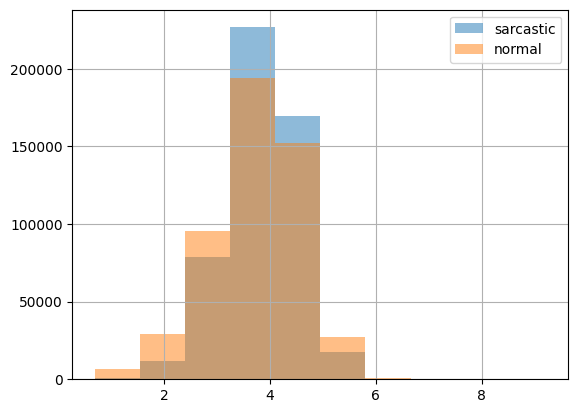

In [13]:
train_df.loc[train_df["label"] == 1, "comment"].str.len().apply(np.log1p).hist(
    label="sarcastic", alpha=0.5
)
train_df.loc[train_df["label"] == 0, "comment"].str.len().apply(np.log1p).hist(
    label="normal", alpha=0.5
)
plt.legend();

In [16]:
from wordcloud import STOPWORDS, WordCloud

In [17]:
wordcloud = WordCloud(
    background_color="black",
    stopwords=STOPWORDS,
    max_words=200,
    max_font_size=100,
    random_state=17,
    width=800,
    height=400,
)

Word cloud are nice, but not very useful

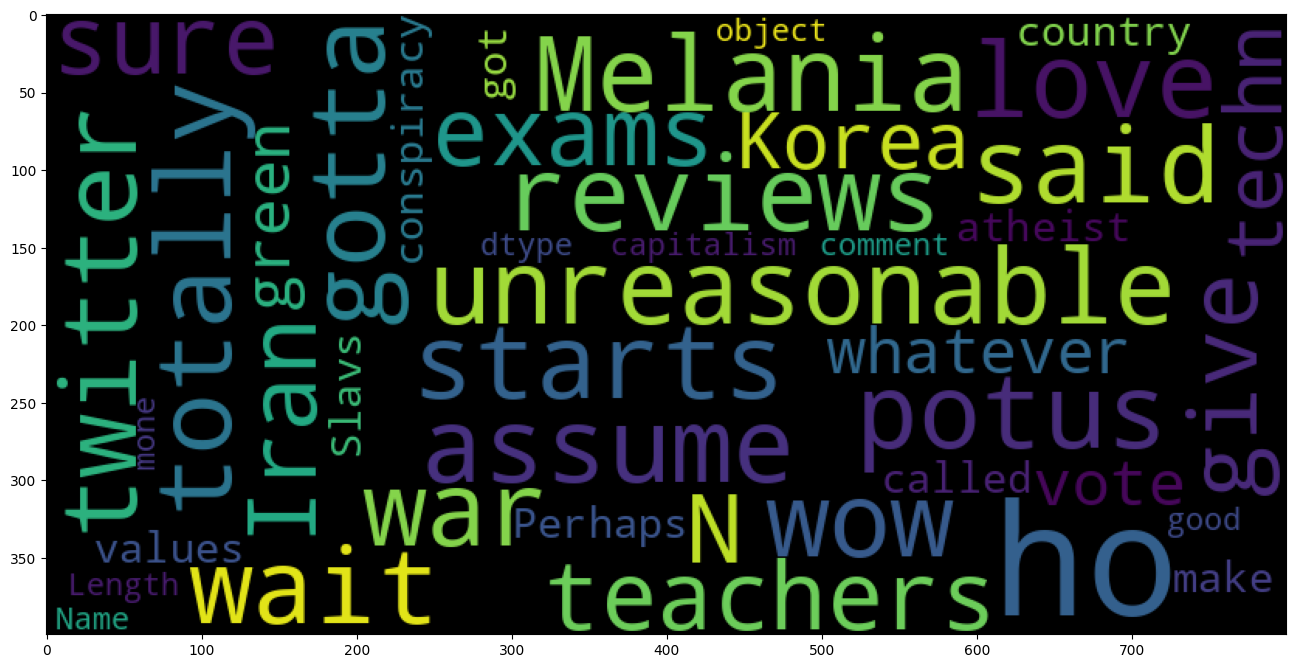

In [18]:
plt.figure(figsize=(16, 12))
wordcloud.generate(str(train_df.loc[train_df["label"] == 1, "comment"]))
plt.imshow(wordcloud);

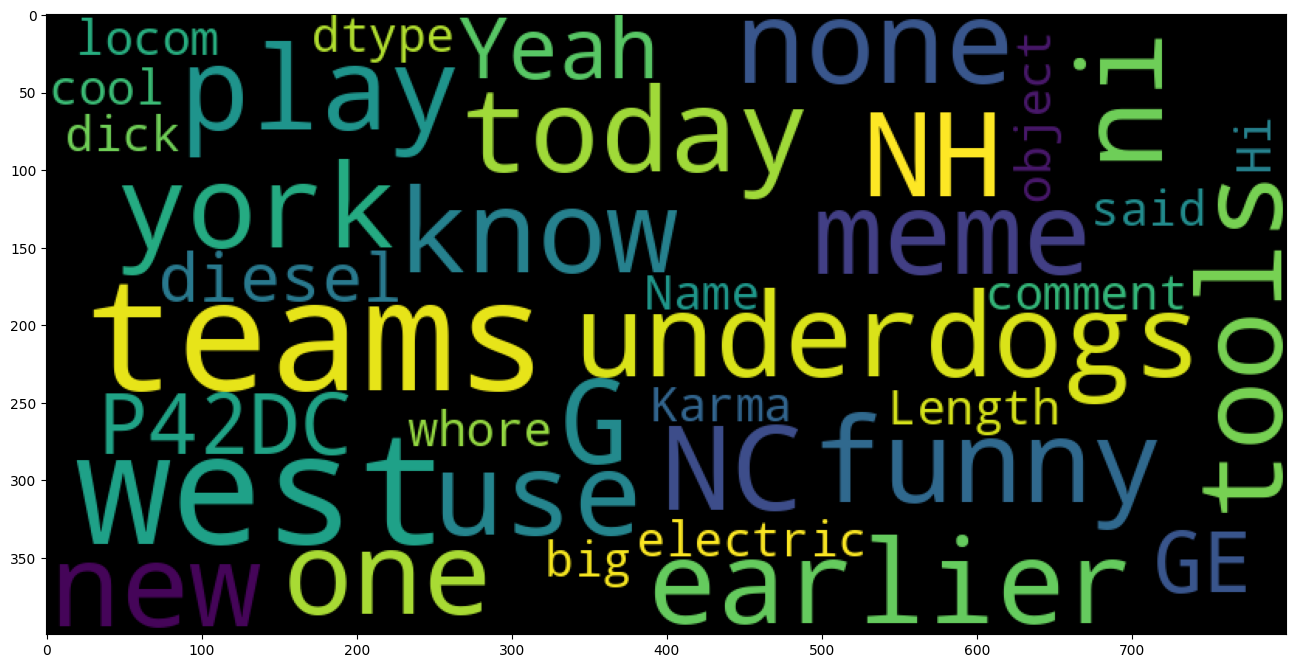

In [19]:
plt.figure(figsize=(16, 12))
wordcloud.generate(str(train_df.loc[train_df["label"] == 0, "comment"]))
plt.imshow(wordcloud);

Let's analyze whether some subreddits are more "sarcastic" on average than others

In [24]:
sub_df = train_df.groupby("subreddit")["label"].agg([np.size, np.mean, np.sum])
sub_df.sort_values(by="sum", ascending=False).head(10)

/tmp/ipykernel_3705452/2599174495.py:1: FutureWarning: The provided callable <function mean at 0x7f10a7671620> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  sub_df = train_df.groupby("subreddit")["label"].agg([np.size, np.mean, np.sum])
/tmp/ipykernel_3705452/2599174495.py:1: FutureWarning: The provided callable <function sum at 0x7f10a7670220> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  sub_df = train_df.groupby("subreddit")["label"].agg([np.size, np.mean, np.sum])


,size,mean,sum
subreddit,,,
AskReddit,65674,0.401453,26365
politics,39493,0.605348,23907
worldnews,26375,0.642540,16947
leagueoflegends,21034,0.542312,11407
pcmasterrace,18987,0.566651,10759
news,16891,0.603457,10193
funny,17939,0.451474,8099
pics,16152,0.484336,7823
todayilearned,14159,0.547567,7753


In [25]:
sub_df[sub_df["size"] > 1000].sort_values(by="mean", ascending=False).head(10)

,size,mean,sum
subreddit,,,
creepyPMs,5466,0.784303,4287
MensRights,3355,0.680775,2284
ShitRedditSays,1284,0.661994,850
worldnews,26375,0.642540,16947
Libertarian,2562,0.640125,1640
atheism,7377,0.639555,4718
Conservative,1881,0.639553,1203
TwoXChromosomes,1560,0.632692,987
fatlogic,2356,0.623090,1468


The same for authors doesn't yield much insight. Except for the fact that somebody's comments were sampled - we can see the same amounts of sarcastic and non-sarcastic comments.

In [26]:
sub_df = train_df.groupby("author")["label"].agg([np.size, np.mean, np.sum])
sub_df[sub_df["size"] > 300].sort_values(by="mean", ascending=False).head(10)

/tmp/ipykernel_3705452/2493728956.py:1: FutureWarning: The provided callable <function mean at 0x7f10a7671620> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  sub_df = train_df.groupby("author")["label"].agg([np.size, np.mean, np.sum])
/tmp/ipykernel_3705452/2493728956.py:1: FutureWarning: The provided callable <function sum at 0x7f10a7670220> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  sub_df = train_df.groupby("author")["label"].agg([np.size, np.mean, np.sum])


,size,mean,sum
author,,,
NeonDisease,422,0.500000,211
ShyBiDude89,404,0.500000,202
ivsciguy,342,0.500000,171
mindlessrabble,302,0.500000,151
mad-n-fla,318,0.500000,159
pokemon_fetish,432,0.500000,216
Biffingston,845,0.499408,422


In [27]:
sub_df = (
    train_df[train_df["score"] >= 0]
    .groupby("score")["label"]
    .agg([np.size, np.mean, np.sum])
)
sub_df[sub_df["size"] > 300].sort_values(by="mean", ascending=False).head(10)

/tmp/ipykernel_3705452/713912710.py:4: FutureWarning: The provided callable <function mean at 0x7f10a7671620> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg([np.size, np.mean, np.sum])
/tmp/ipykernel_3705452/713912710.py:4: FutureWarning: The provided callable <function sum at 0x7f10a7670220> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg([np.size, np.mean, np.sum])


,size,mean,sum
score,,,
0,58141,0.612752,35626
20,3096,0.561370,1738
34,1071,0.556489,596
26,1874,0.554429,1039
59,315,0.552381,174
18,3951,0.551759,2180
13,7277,0.546929,3980
17,4404,0.545867,2404
40,722,0.545706,394


In [33]:
sub_df = (
    train_df[train_df["score"] < 0]
    .groupby("score")["label"]
    .agg([np.size, np.mean, np.sum])
)
sub_df[sub_df["size"] > 300].sort_values(by="mean", ascending=False).head(10)

/tmp/ipykernel_3705452/341200494.py:4: FutureWarning: The provided callable <function mean at 0x7f10a7671620> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  .agg([np.size, np.mean, np.sum])
/tmp/ipykernel_3705452/341200494.py:4: FutureWarning: The provided callable <function sum at 0x7f10a7670220> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg([np.size, np.mean, np.sum])


,size,mean,sum
score,,,
-14,537,0.698324,375
-8,1852,0.696004,1289
-9,1503,0.691284,1039
-6,3088,0.688795,2127
-12,776,0.684278,531
-5,4134,0.678520,2805
-3,6736,0.676069,4554
-2,11924,0.675948,8060
-4,5436,0.673473,3661


### Part 2. Training the model

In [34]:
# build bigrams, put a limit on maximal number of features
# and minimal word frequency
tf_idf = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2)
# multinomial logistic regression a.k.a softmax classifier
logit = LogisticRegression(C=1, n_jobs=4, solver="lbfgs", random_state=17, verbose=1)
# sklearn's pipeline
tfidf_logit_pipeline = Pipeline([("tf_idf", tf_idf), ("logit", logit)])

In [35]:
%%time
tfidf_logit_pipeline.fit(train_texts, y_train)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


CPU times: user 14.3 s, sys: 369 ms, total: 14.6 s
Wall time: 24.3 s


,steps,"[('tf_idf', ...), ('logit', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [36]:
%%time
valid_pred = tfidf_logit_pipeline.predict(valid_texts)

CPU times: user 3 s, sys: 28.2 ms, total: 3.03 s
Wall time: 3.04 s


In [37]:
accuracy_score(y_valid, valid_pred)

0.7200278598932301

### Part 3. Explaining the model

In [38]:
def plot_confusion_matrix(
    actual,
    predicted,
    classes,
    normalize=False,
    title="Confusion matrix",
    figsize=(7, 7),
    cmap=plt.cm.Blues,
    path_to_save_fig=None,
):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    import itertools

    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(actual, predicted).T
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=figsize)
    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=90)
    plt.yticks(tick_marks, classes)

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
        )

    plt.tight_layout()
    plt.ylabel("Predicted label")
    plt.xlabel("True label")

    if path_to_save_fig:
        plt.savefig(path_to_save_fig, dpi=300, bbox_inches="tight")

Confusion matrix is quite balanced.

In [44]:
print(confusion_matrix(y_valid, valid_pred, labels=tfidf_logit_pipeline.named_steps["logit"].classes_))
print(tfidf_logit_pipeline.named_steps["logit"].classes_)

[[95507 30426]
 [40321 86439]]
[0 1]


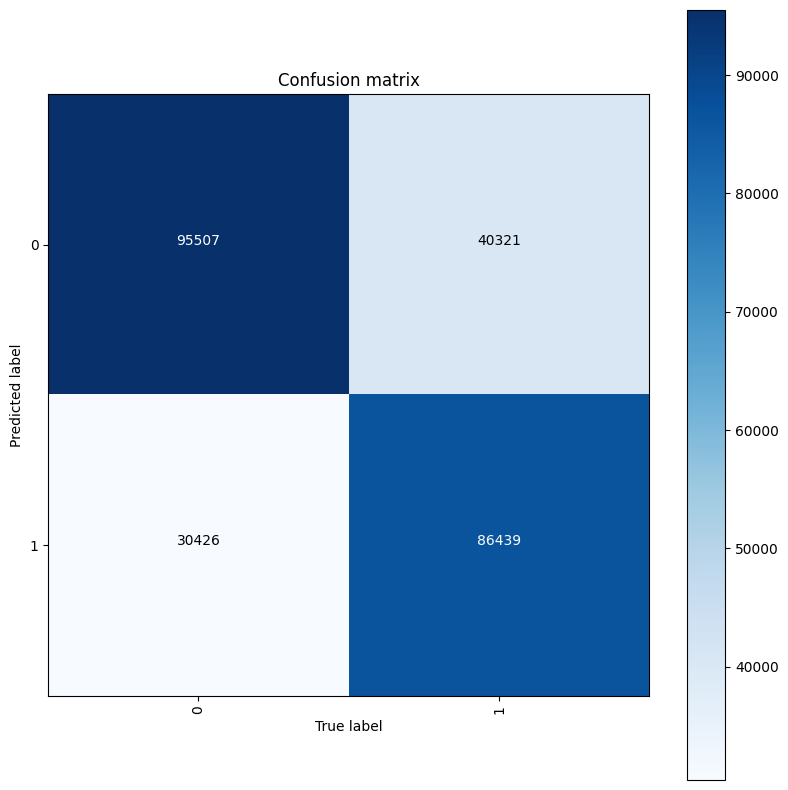

In [39]:
plot_confusion_matrix(
    y_valid,
    valid_pred,
    tfidf_logit_pipeline.named_steps["logit"].classes_,
    figsize=(8, 8),
)

Indeed, we can recognize some phrases indicative of sarcasm. Like "yes sure". 

In [47]:
import eli5

eli5.show_weights(
    estimator=tfidf_logit_pipeline.named_steps["logit"],
    vec=tfidf_logit_pipeline.named_steps["tf_idf"],
)

Weight?,Feature
+9.755,yes because
+8.044,clearly
+7.956,obviously
+7.362,totally
+6.999,yeah because
+6.448,because
+5.799,right because
+5.713,how dare
+5.428,but thought
+5.240,duh


So sarcasm detection is easy.
<img src="https://habrastorage.org/webt/1f/0d/ta/1f0dtavsd14ncf17gbsy1cvoga4.jpeg" />

### Part 4. Improving the model

In [48]:
subreddits = train_df["subreddit"]
train_subreddits, valid_subreddits = train_test_split(subreddits, random_state=17)

We'll have separate Tf-Idf vectorizers for comments and for subreddits. It's possible to stick to a pipeline as well, but in that case it becomes a bit less straightforward. [Example](https://stackoverflow.com/questions/36731813/computing-separate-tfidf-scores-for-two-different-columns-using-sklearn)

In [49]:
tf_idf_texts = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, min_df=2)
tf_idf_subreddits = TfidfVectorizer(ngram_range=(1, 1))

Do transformations separately for comments and subreddits. 

In [50]:
%%time
X_train_texts = tf_idf_texts.fit_transform(train_texts)
X_valid_texts = tf_idf_texts.transform(valid_texts)

CPU times: user 17.8 s, sys: 1.69 s, total: 19.5 s
Wall time: 19.6 s


In [51]:
X_train_texts.shape, X_valid_texts.shape

((758078, 50000), (252693, 50000))

In [52]:
%%time
X_train_subreddits = tf_idf_subreddits.fit_transform(train_subreddits)
X_valid_subreddits = tf_idf_subreddits.transform(valid_subreddits)

CPU times: user 1.78 s, sys: 10.1 ms, total: 1.79 s
Wall time: 1.8 s


In [53]:
X_train_subreddits.shape, X_valid_subreddits.shape

((758078, 13238), (252693, 13238))

Then, stack all features together.

In [54]:
from scipy.sparse import hstack

X_train = hstack([X_train_texts, X_train_subreddits])
X_valid = hstack([X_valid_texts, X_valid_subreddits])

In [55]:
X_train.shape, X_valid.shape

((758078, 63238), (252693, 63238))

Train the same logistic regression.

In [56]:
logit.fit(X_train, y_train)

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
/opt/d.sidorko/ocr_research/study/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,17
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [57]:
%%time
valid_pred = logit.predict(X_valid)

CPU times: user 9.57 ms, sys: 1.88 ms, total: 11.4 ms
Wall time: 10.2 ms


In [58]:
accuracy_score(y_valid, valid_pred)

0.7226357675123569

As we can see, accuracy slightly increased.

## Links:
  - Machine learning library [Scikit-learn](https://scikit-learn.org/stable/index.html) (a.k.a. sklearn)
  - Kernels on [logistic regression](https://www.kaggle.com/kashnitsky/topic-4-linear-models-part-2-classification) and its applications to [text classification](https://www.kaggle.com/kashnitsky/topic-4-linear-models-part-4-more-of-logit), also a [Kernel](https://www.kaggle.com/kashnitsky/topic-6-feature-engineering-and-feature-selection) on feature engineering and feature selection
  - [Kaggle Kernel](https://www.kaggle.com/abhishek/approaching-almost-any-nlp-problem-on-kaggle) "Approaching (Almost) Any NLP Problem on Kaggle"
  - [ELI5](https://github.com/TeamHG-Memex/eli5) to explain model predictions